<a href="https://colab.research.google.com/github/LielUziahu/12th_GetTogether/blob/main/combined_settlement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Block 1: Data Loading, Cleaning, and Phenotype Filtering.
In this block, we standardize the column names and morph labels from your four different CSV files, remove the "Partial Fluorescent" (PF) data as requested by your PI, and merge them into a single "Master" dataset for analysis.

In [1]:
import pandas as pd
import numpy as np

# --- HELPER FUNCTION ---
def clean_morph(val):
    """Standardizes morph labels and handles typos/extra spaces."""
    val = str(val).strip().lower()
    if 'high' in val or 'hf' == val:
        return 'HF'
    if 'no' in val or 'nf' == val:
        return 'NF'
    if 'partial' in val or 'pf' == val:
        return 'PF'
    return None

# ==========================================
# BLOCK 1: LOADING & STANDARDIZING DATA
# ==========================================

# 1. Load Ambient (Control)
df_amb = pd.read_csv("Settlment_Ambient.csv")
df_amb['morph'] = df_amb['Varient'].apply(clean_morph)
df_amb = df_amb.rename(columns={'setteled %': 'settlement'})[['morph', 'settlement']]
df_amb['Treatment'] = 'Ambient'

# 2. Load Depth (Light) - Filtering for 50m and Dark
df_depth = pd.read_csv("Settlement_Depth.csv")
df_depth['morph'] = df_depth['fluorescense level'].apply(clean_morph)
df_depth['settlement'] = pd.to_numeric(df_depth['setteled %'], errors='coerce')
# We exclude '10m' here because it is covered by the 'Ambient' control
df_depth = df_depth[df_depth['Light'].astype(str).str.upper().isin(['50M', 'DARK'])].copy()
df_depth['Treatment'] = df_depth['Light'].str.capitalize()

# 3. Load pH Stress
df_ph = pd.read_csv("Settlement_pH.csv")
df_ph['morph'] = df_ph['fluorescense level'].apply(clean_morph)
df_ph['settlement'] = pd.to_numeric(df_ph['setteled %'], errors='coerce')
df_ph = df_ph[df_ph['pH'].astype(str).isin(['7.8', '7.6'])].copy()
df_ph['Treatment'] = 'pH ' + df_ph['pH'].astype(str)

# 4. Load Thermal Stress
df_temp = pd.read_csv("Settlement_Temp.csv")
df_temp['morph'] = df_temp['fluorescense level'].apply(clean_morph)
df_temp['settlement'] = pd.to_numeric(df_temp['setteled %'], errors='coerce')
df_temp = df_temp[df_temp['Temp'].astype(float).isin([27, 32])].copy()
df_temp['Treatment'] = df_temp['Temp'].astype(float).astype(int).astype(str) + '°C'

# 5. Combine all into Master DataFrame and REMOVE 'PF'
master_df = pd.concat([
    df_amb,
    df_depth[['morph', 'settlement', 'Treatment']],
    df_ph[['morph', 'settlement', 'Treatment']],
    df_temp[['morph', 'settlement', 'Treatment']]
])

# Final Cleaning: Drop rows with missing values and remove the PF morph
master_df = master_df.dropna(subset=['morph', 'settlement'])
master_df = master_df[master_df['morph'] != 'PF'].copy()

print(f"Block 1 Complete.")
print(f"Total observations: {len(master_df)}")
print(f"Morphs remaining: {master_df['morph'].unique()}")
print(f"Treatments loaded: {master_df['Treatment'].unique().tolist()}")
print(master_df.head())

Block 1 Complete.
Total observations: 126
Morphs remaining: ['NF' 'HF']
Treatments loaded: ['Ambient', '50m', 'Dark', 'pH 7.8', 'pH 7.6', '27°C', '32°C']
  morph  settlement Treatment
0    NF        15.0   Ambient
1    NF        70.0   Ambient
2    NF        30.0   Ambient
3    NF        20.0   Ambient
4    NF        70.0   Ambient


# Block 2: Outlier Removal via 1.5*IQR.
This block ensures that technical "noise" or extreme values don't skew your final results. We perform this calculation separately for each group (e.g., HF in Ambient vs. NF in Ambient) to account for the natural variance within each phenotype.

In [2]:
# ==========================================
# BLOCK 2: OUTLIER REMOVAL (1.5 * IQR)
# ==========================================

def remove_outliers_iqr(df, group_cols, target_col):
    """
    Filters out rows that are outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
    calculated per specific experimental group.
    """
    def filter_group(group):
        q1 = group[target_col].quantile(0.25)
        q3 = group[target_col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # Return only the values within the bounds
        return group[(group[target_col] >= lower_bound) & (group[target_col] <= upper_bound)]

    return df.groupby(group_cols, group_keys=False).apply(filter_group)

# Count before removal for reporting
count_before = len(master_df)

# Apply outlier removal per Morph and Treatment
master_df_clean = remove_outliers_iqr(master_df, ['morph', 'Treatment'], 'settlement')

# Calculate how many were removed
count_after = len(master_df_clean)
removed_count = count_before - count_after

print(f"Block 2 Complete.")
print(f"Outliers removed: {removed_count}")
print(f"Remaining data points for analysis: {count_after}")

# Summary of N per group after cleaning
print("\nSample size per group (N):")
print(master_df_clean.groupby(['Treatment', 'morph']).size().unstack(fill_value=0))

Block 2 Complete.
Outliers removed: 4
Remaining data points for analysis: 122

Sample size per group (N):
morph      HF  NF
Treatment        
27°C        9   7
32°C       10   7
50m         5   6
Ambient    25  21
Dark        6   6
pH 7.6      5   5
pH 7.8      5   5


/tmp/ipykernel_5902/1513214813.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols, group_keys=False).apply(filter_group)


# Block 3: Normality Check (Shapiro-Wilk Test).
This block is essential for determining whether your data follows a normal distribution. In scientific publishing, this step dictates which statistical test is appropriate: a Parametric test (like a T-test or ANOVA) if the data is normal, or a Non-Parametric test (like Mann-Whitney U or Kruskal-Wallis) if it is not.

In [3]:
from scipy import stats

# ==========================================
# BLOCK 3: NORMALITY CHECK (SHAPIRO-WILK)
# ==========================================

print("--- BLOCK 3: RUNNING NORMALITY CHECKS ---")

normality_results = []

# Iterate through every experimental group to test for normality
for (treat, morph), group in master_df_clean.groupby(['Treatment', 'morph']):
    data = group['settlement']

    # Shapiro-Wilk requires at least 3 samples
    if len(data) >= 3:
        shapiro_stat, p_value = stats.shapiro(data)
        is_normal = p_value > 0.05  # Standard alpha threshold
    else:
        # If N < 3, we cannot reliably test normality
        shapiro_stat, p_value = np.nan, np.nan
        is_normal = False

    normality_results.append({
        'Treatment': treat,
        'Morph': morph,
        'N': len(data),
        'W_Statistic': shapiro_stat,
        'p_value': p_value,
        'Normal_Distribution': is_normal
    })

# Convert results to a DataFrame for easy viewing
normality_df = pd.DataFrame(normality_results)

# Display the report
print("\n[NORMALITY REPORT]")
print(normality_df.to_string(index=False))

# Calculate global status
failed_groups = normality_df[normality_df['Normal_Distribution'] == False]
if failed_groups.empty:
    print("\nCONCLUSION: All groups are normally distributed. Use PARAMETRIC tests (T-test/ANOVA).")
else:
    print(f"\nCONCLUSION: {len(failed_groups)} groups failed the normality test.")
    print("ACTION: The pipeline will automatically use NON-PARAMETRIC tests (Mann-Whitney U) for these conditions.")

--- BLOCK 3: RUNNING NORMALITY CHECKS ---

[NORMALITY REPORT]
Treatment Morph  N  W_Statistic  p_value  Normal_Distribution
     27°C    HF  9     0.938487 0.566067                 True
     27°C    NF  7     0.937287 0.614417                 True
     32°C    HF 10     0.823614 0.028023                False
     32°C    NF  7     0.899899 0.330371                 True
      50m    HF  5     0.881038 0.314040                 True
      50m    NF  6     0.931672 0.593073                 True
  Ambient    HF 25     0.939298 0.142605                 True
  Ambient    NF 21     0.882864 0.016513                False
     Dark    HF  6     0.913352 0.458810                 True
     Dark    NF  6     0.684207 0.004196                False
   pH 7.6    HF  5     0.684029 0.006470                False
   pH 7.6    NF  5     0.766717 0.042199                False
   pH 7.8    HF  5     0.978716 0.927636                 True
   pH 7.8    NF  5     0.952960 0.758312                 True

CONCLUS

# Block 4: Automated Statistical Analysis.
This block uses the results from the normality check in Block 3 to decide which test to perform for each environmental condition. It compares the High Fluorescent (HF) and Non-Fluorescent (NF) morphs directly to see where the phenotypic advantages lie.

In [4]:
# ==========================================
# BLOCK 4: AUTOMATED STATISTICAL ANALYSIS
# ==========================================

print("--- BLOCK 4: PERFORMING COMPARATIVE STATS ---")

stats_results = []

# Analyze each Treatment condition separately
for treat in master_df_clean['Treatment'].unique():
    # Subset data for this specific stressor
    subset = master_df_clean[master_df_clean['Treatment'] == treat]
    hf_data = subset[subset['morph'] == 'HF']['settlement']
    nf_data = subset[subset['morph'] == 'NF']['settlement']

    # 1. Determine which test to use based on Normality results for THIS treatment
    # We check if BOTH morphs in this treatment passed the normality test (p > 0.05)
    subset_normality = normality_df[normality_df['Treatment'] == treat]
    is_normal = subset_normality['Normal_Distribution'].all()

    if is_normal:
        # PARAMETRIC: Independent T-test
        stat, p_val = stats.ttest_ind(hf_data, nf_data)
        test_name = "Independent T-test"
    else:
        # NON-PARAMETRIC: Mann-Whitney U test
        stat, p_val = stats.mannwhitneyu(hf_data, nf_data)
        test_name = "Mann-Whitney U"

    # 2. Log the results
    stats_results.append({
        'Condition': treat,
        'HF_Mean': hf_data.mean(),
        'NF_Mean': nf_data.mean(),
        'Difference': hf_data.mean() - nf_data.mean(),
        'p_value': p_val,
        'Test_Used': test_name,
        'Significant': p_val < 0.05
    })

# Convert to DataFrame for the final poster report
results_df = pd.DataFrame(stats_results)

# Display the Final Statistical Summary
print("\n[FINAL SETTLEMENT ANALYSIS SUMMARY]")
print(results_df[['Condition', 'HF_Mean', 'NF_Mean', 'p_value', 'Significant', 'Test_Used']].to_string(index=False))

# Save this summary to a CSV for your records
results_df.to_csv("Settlement_Statistical_Results.csv", index=False)

--- BLOCK 4: PERFORMING COMPARATIVE STATS ---

[FINAL SETTLEMENT ANALYSIS SUMMARY]
Condition   HF_Mean   NF_Mean  p_value  Significant          Test_Used
     27°C 36.666667 35.714286 0.947607        False Independent T-test
     32°C 22.000000 18.571429 1.000000        False     Mann-Whitney U
      50m 68.000000 43.333333 0.161353        False Independent T-test
  Ambient 50.800000 35.238095 0.012169         True     Mann-Whitney U
     Dark 28.333333 35.000000 0.459148        False     Mann-Whitney U
   pH 7.6 42.000000 20.000000 0.076416        False     Mann-Whitney U
   pH 7.8 48.000000 26.000000 0.110175        False Independent T-test


In [21]:
master_df_clean['Treatment'] = master_df_clean['Treatment'].replace('Ambient (23°C, pH 8.2, 10m)', 'Ambient \n(23°C, pH 8.2, 10m)')

# Update the order list for plotting
order = ['Ambient \n(23°C, pH 8.2, 10m)', '27°C', '32°C', 'pH 7.8', 'pH 7.6', '50m', 'Dark']

# Block 5: High-Impact Visualization (The "Master Plot").
This block generates a publication-quality figure specifically designed for your 90x120 cm portrait poster. It combines the raw data points (to show variance) with boxplots (to show medians) and adds significance markers based on the results from Block 4.

--- BLOCK 5 COMPLETE ---
Figure saved as 'Master_Settlement_Poster_Plot.png'.


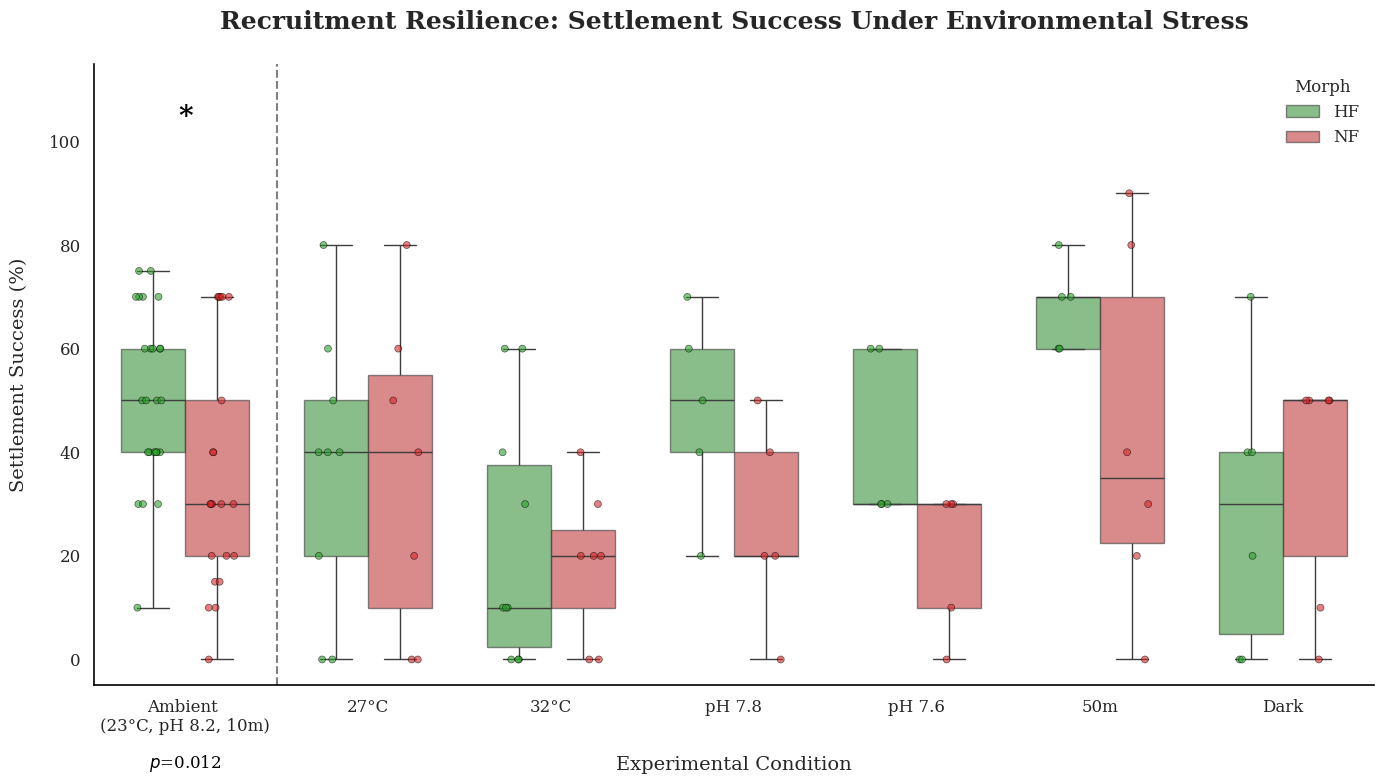

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ==========================================
# BLOCK 5: HIGH-IMPACT VISUALIZATION
# ==========================================

# 1. Setup Aesthetics
sns.set_theme(style="white")
plt.rcParams.update(
    {
        "font.family": "serif",
        "axes.edgecolor": "black",
        "axes.linewidth": 1.2,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
)

# Define colors (consistent with your previous plots)
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}

# 2. Prepare Plot Data
# The 'order' list has been updated in the previous cell to include the detailed Ambient label.
# We will use the 'order' variable defined globally.

# DEBUGGING: Print unique treatments and order list to identify discrepancy
# print("Unique treatments in master_df_clean:", master_df_clean['Treatment'].unique())
# print("Order list used for plotting:", order)
# End DEBUGGING

fig, ax = plt.subplots(figsize=(14, 8))

# Draw Boxplots (Medians and IQRs)
sns.boxplot(
    data=master_df_clean, x='Treatment', y='settlement', hue='morph',
    order=order, palette=variant_colors, ax=ax,
    width=0.7, boxprops=dict(alpha=0.6), showfliers=False
)

# Overlay individual data points (Raw jitter)
sns.stripplot(
    data=master_df_clean, x='Treatment', y='settlement', hue='morph',
    order=order, palette=variant_colors, ax=ax,
    dodge=True, size=5, alpha=0.6, jitter=0.15, edgecolor='black', linewidth=0.5
)

# 3. Add Significance Markers
# Based on Block 4 results: Ambient (p=0.012) was significant.
# We'll place an asterisk above the Ambient group.
# The position needs to be adjusted as the x-axis label has changed.
# Ambient is the first item in the 'order' list, so its index is 0.
ax.text(0, 102, "*", ha='center', va='bottom', color='black', fontsize=20, fontweight='bold')

# Find the p-value for Ambient from results_df
ambient_p_value = results_df[results_df['Condition'] == 'Ambient']['p_value'].iloc[0]
# Place the p-value text below the x-axis label for Ambient, with italic 'p'
ax.text(0, -18, f"$p$={ambient_p_value:.3f}", ha='center', va='top', color='black', fontsize=12)

# Add a vertical line after the Ambient group to visually separate it
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=1.5)

# 4. Final Polish
ax.set_title("Recruitment Resilience: Settlement Success Under Environmental Stress",
             fontsize=18, fontweight='bold', pad=25)
ax.set_xlabel("Experimental Condition", fontsize=14, labelpad=15)
ax.set_ylabel("Settlement Success (%)", fontsize=14, labelpad=15)
ax.set_ylim(-5, 115) # Leave space for significance marks at the top

# Clean up legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], ["HF", "NF"],
          title="Morph", loc='upper right', frameon=False, fontsize=12)

sns.despine()
plt.tight_layout()

# Save for the poster (600 DPI is critical for large prints)
plt.savefig("Master_Settlement_Poster_Plot.png", dpi=600, bbox_inches='tight')
plt.savefig("Master_Settlement_Poster_Plot.pdf", dpi=600, bbox_inches='tight')
plt.savefig("Master_Settlement_Poster_Plot.svg", dpi=600, bbox_inches='tight')
plt.savefig("Master_Settlement_Poster_Plot.tiff", dpi=600, bbox_inches='tight')

print("--- BLOCK 5 COMPLETE ---")
print("Figure saved as 'Master_Settlement_Poster_Plot.png'.")